In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("Environment is working!")

NumPy version: 2.5.3
Pandas version: 3.0.5
Scikit-learn version: 1.9.1
Environment is working!


In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("../Spam Email Classification/data/spam.csv", encoding="latin-1")

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.shape

(5572, 5)

In [8]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [10]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [11]:
df[['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']].dropna(how='all').head(10)

,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,"this wont even start........ Datz confidence..""",NaN,NaN
899,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,GN,GE,"GNT:-)"""
1127,".;-):-D""",NaN,NaN
1266,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,"bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [12]:
df = df[['v1', 'v2']]

In [13]:
df['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [14]:
df['v1'].value_counts(normalize=True) * 100

v1
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

In [15]:
df = df[['v1', 'v2']]

In [16]:
df = df.rename(columns={
    'v1': 'label',
    'v2': 'message'
})

In [17]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
df.columns

Index(['label', 'message'], dtype='str')

In [19]:
df['label']

0        ham
1        ham
2       spam
3        ham
4        ham
        ... 
5567    spam
5568     ham
5569     ham
5570     ham
5571     ham
Name: label, Length: 5572, dtype: str

In [20]:
df.duplicated().sum()

np.int64(403)

In [21]:
df[df.duplicated()].head(10)

,label,message
102,ham,As per your request 'Melle Melle (Oru Minnamin...
153,ham,As per your request 'Melle Melle (Oru Minnamin...
206,ham,"As I entered my cabin my PA said, '' Happy B'd..."
222,ham,"Sorry, I'll call later"
325,ham,No calls..messages..missed calls
338,ham,"Sorry, I'll call later"
356,spam,Congratulations ur awarded 500 of CD vouchers ...
443,ham,"Sorry, I'll call later"
532,ham,Gudnite....tc...practice going on
654,ham,Did u got that persons story


In [22]:
df['message_length'] = df['message'].str.len()

In [23]:
df[['message', 'message_length']].head()

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


In [24]:
df.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.023627,58.016023,2.0,33.0,52.0,92.0,910.0
spam,747.0,138.866131,29.183082,13.0,132.5,149.0,157.0,224.0


In [25]:
df = df.drop_duplicates()

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Dataset shape after removing duplicates: (5169, 3)
Remaining duplicates: 0


In [28]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

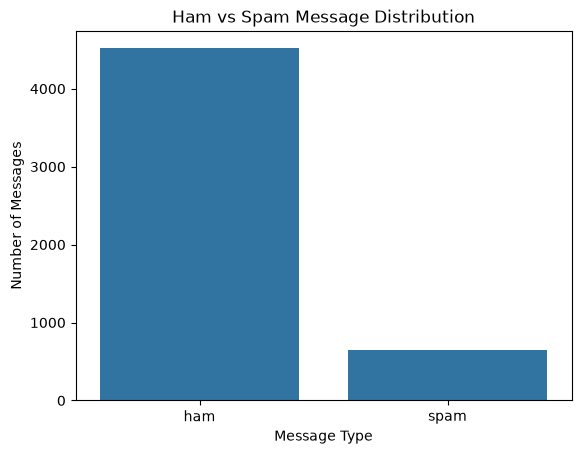

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='label')

plt.title('Ham vs Spam Message Distribution')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')
plt.show()

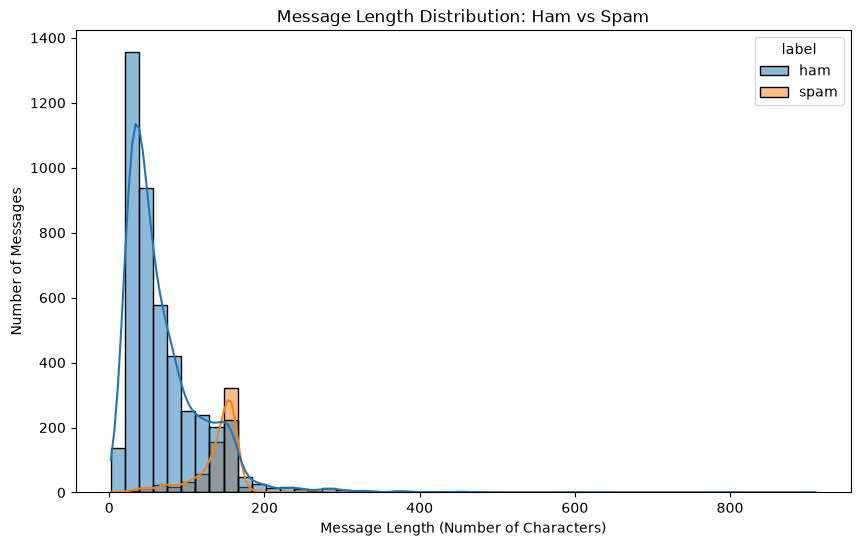

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    bins=50,
    kde=True
)

plt.title('Message Length Distribution: Ham vs Spam')
plt.xlabel('Message Length (Number of Characters)')
plt.ylabel('Number of Messages')
plt.show()

In [31]:
from collections import Counter
import re

# Get all words from spam messages
spam_text = ' '.join(df[df['label'] == 'spam']['message'])

# Convert to lowercase and extract words
spam_words = re.findall(r'\b[a-zA-Z]+\b', spam_text.lower())

# Count words
spam_word_counts = Counter(spam_words)

# Display the 20 most common spam words
print("Top 20 words in spam messages:")
print(spam_word_counts.most_common(20))

Top 20 words in spam messages:
[('to', 596), ('a', 332), ('call', 309), ('you', 268), ('your', 242), ('free', 195), ('for', 184), ('the', 183), ('now', 164), ('or', 157), ('u', 147), ('is', 144), ('txt', 134), ('from', 122), ('on', 121), ('ur', 119), ('have', 115), ('mobile', 109), ('stop', 109), ('text', 108)]


In [32]:
print("Original messages:\n")

for message in df['message'].head(10):
    print(message)
    print("-" * 80)

Original messages:

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
--------------------------------------------------------------------------------
Ok lar... Joking wif u oni...
--------------------------------------------------------------------------------
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
--------------------------------------------------------------------------------
U dun say so early hor... U c already then say...
--------------------------------------------------------------------------------
Nah I don't think he goes to usf, he lives around here though
--------------------------------------------------------------------------------
FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv
----------------

In [33]:
df['clean_message'] = df['message'].str.lower()

print(df[['message', 'clean_message']].head(10))

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   
5  FreeMsg Hey there darling it's been 3 week's n...   
6  Even my brother is not like to speak with me. ...   
7  As per your request 'Melle Melle (Oru Minnamin...   
8  WINNER!! As a valued network customer you have...   
9  Had your mobile 11 months or more? U R entitle...   

                                       clean_message  
0  go until jurong point, crazy.. available only ...  
1                      ok lar... joking wif u oni...  
2  free entry in 2 a wkly comp to win fa cup fina...  
3  u dun say so early hor... u c already then say...  
4  nah i don't think he goes to usf, he lives aro...  
5  freemsg hey there darling it's been 3 week's n... 

In [34]:
import re

df['clean_message'] = df['clean_message'].apply(
    lambda text: re.sub(r'[^a-zA-Z0-9\s]', '', text)
)

print(df[['message', 'clean_message']].head(10))

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   
5  FreeMsg Hey there darling it's been 3 week's n...   
6  Even my brother is not like to speak with me. ...   
7  As per your request 'Melle Melle (Oru Minnamin...   
8  WINNER!! As a valued network customer you have...   
9  Had your mobile 11 months or more? U R entitle...   

                                       clean_message  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in 2 a wkly comp to win fa cup fina...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  
5  freemsg hey there darling its been 3 weeks now... 

In [35]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print("Number of English stopwords:", len(ENGLISH_STOP_WORDS))
print("Some stopwords:")
print(list(ENGLISH_STOP_WORDS)[:30])

Number of English stopwords: 318
Some stopwords:
['sometimes', 'eight', 'amongst', 'as', 'whole', 'anything', 'sometime', 'its', 'since', 'himself', 'has', 'thereby', 'due', 'neither', 'had', 'ourselves', 'us', 'beside', 'after', 'otherwise', 'so', 'thin', 'those', 'below', 'back', 'a', 'front', 'detail', 'therein', 'get']


In [36]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

df['clean_message'] = df['clean_message'].apply(
    lambda text: ' '.join(
        word for word in text.split()
        if word not in ENGLISH_STOP_WORDS
    )
)

print(df[['message', 'clean_message']].head(10))

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   
5  FreeMsg Hey there darling it's been 3 week's n...   
6  Even my brother is not like to speak with me. ...   
7  As per your request 'Melle Melle (Oru Minnamin...   
8  WINNER!! As a valued network customer you have...   
9  Had your mobile 11 months or more? U R entitle...   

                                       clean_message  
0  jurong point crazy available bugis n great wor...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                        u dun say early hor u c say  
4                      nah dont think goes usf lives  
5  freemsg hey darling 3 weeks word id like fun t... 

In [37]:
X = df['clean_message']
y = df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nLabels:")
print(y.value_counts())

X shape: (5169,)
y shape: (5169,)

Labels:
label
ham     4516
spam     653
Name: count, dtype: int64


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training samples: 4135
Testing samples: 1034

Training label distribution:
label
ham     3613
spam     522
Name: count, dtype: int64

Testing label distribution:
label
ham     903
spam    131
Name: count, dtype: int64


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 7902)
Testing TF-IDF shape: (1034, 7902)
